In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cmocean  # Paleta de cores oceânicas
import ipympl
# import rioxarray  # Extensão do xarray para manipulação de rasters
# import rasterio

In [3]:
file_path = "/mnt/c/Users/henri/OneDrive - atmosmarine.com/GEBCO/gebco_2024/gebco_2024.nc"  # Substitua pelo caminho correto
ds_gebco = xr.open_dataset(file_path)
ds_gebco_rj = ds_gebco.sel(lat=slice(-23.5, -22.5), lon=slice(-44.0, -42.0))
# ds_gebco_rj.to_netcdf('RJ/NCfiles/batimetria_rj_gebco2024.nc')
# ds_gebco_rj.close()

lat = ds_gebco_rj.lat.values
lon = ds_gebco_rj.lon.values

In [4]:
ds_gebco_rj

<xarray.Dataset> Size: 236kB
Dimensions:    (lon: 480, lat: 240)
Coordinates:
  * lon        (lon) float64 4kB -44.0 -43.99 -43.99 ... -42.01 -42.01 -42.0
  * lat        (lat) float64 2kB -23.5 -23.49 -23.49 ... -22.51 -22.51 -22.5
Data variables:
    crs        |S1 1B ...
    elevation  (lat, lon) int16 230kB ...
Attributes: (12/36)
    title:                           The GEBCO_2024 Grid - a continuous terra...
    summary:                         The GEBCO_2024 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_vertical_units:       meters
    geospatial_vertical_resolution:  1.0
    geospatial_vertical_positive:    up
    identifier_product_doi:          DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    references:                      DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    node_offset:                     1.0

In [5]:
print (ds_gebco_rj.lon.values[0] - ds_gebco_rj.lon.values[-1])
print (ds_gebco_rj.lat.values[0] - ds_gebco_rj.lat.values[-1])

-1.9958333333333371
-0.9958333333333371


In [14]:
bathymetry = ds_gebco_rj.elevation.values * -1.0
np.savetxt("RJ/Inputs/RJ_batimetria.bot", bathymetry, fmt="%d", delimiter='\t')

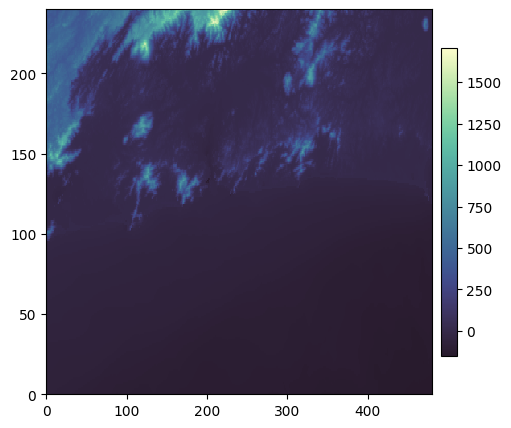

In [7]:

# bathymetry = np.flipud(bathymetry)
# bathymetry = bathymetry.T
# bathymetry = bathymetry.T

plt.close('all')
%matplotlib inline

fig, ax = plt.subplots(figsize=(6, 5))#, subplot_kw={'projection': ccrs.PlateCarree()})

# ax.contour(lon, lat, bathymetry)
cc = ax.pcolor(bathymetry,
               cmap=cmocean.cm.deep_r,
            #    levels=[-100, -50, 0, 50, 100],
            #    extend='both'
               )

cbar = fig.colorbar(cc, ax=ax, orientation="vertical", shrink=0.8, pad=0.02)

plt.show()

/mnt/c/Users/henri/git/SWAN-MAT/venv/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1646: UserWarning: The following kwargs were not used by contour: 'cbar_kwargs'
  result = super().contourf(*args, **kwargs)


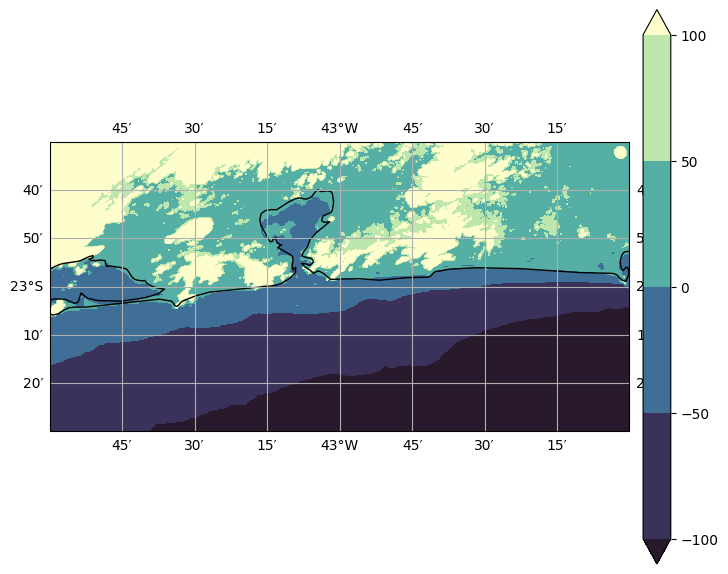

In [8]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': ccrs.PlateCarree()})

ax.coastlines(resolution='10m')
# ax.add_feature(cfeature.GSHHSFeature(scale='high'), edgecolor='black')
# Plot da elevação com ajustes na barra de cores

elev_plot = ax.contourf(lon, lat, ds_gebco_rj.elevation.values, cmap=cmocean.cm.deep_r,  
                       levels=[-100, -50, 0, 50, 100],
                       extend='both',
                    #    vmin=-50, vmax=50,
                        transform=ccrs.PlateCarree(),
                        cbar_kwargs={'label': 'Elevação (m)', 
                                    'shrink': 0.1,  # Reduz o tamanho da barra
                                    'pad': 0.02,  # Aproxima da figura
                                    'aspect': 20,  # Ajusta proporção altura/largura
                                    'fraction': 0.05,  # Reduz o espaço ocupado
                                    'fontsize': 8, # Diminui a fonte da legenda
                                    }
                                    )

# Adicionando camada de costa com alta resolução
# ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '10m'),
#                facecolor='none', edgecolor='black', linewidth=1)

ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

cbar = fig.colorbar(elev_plot, ax=ax, orientation="vertical", shrink=0.8, pad=0.02)
# Adicionando grade de coordenadas
# gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)
# gl.right_labels = False
# gl.top_labels = False

# Definir limites para a Baía de Guanabara
# ax.set_xlim(-43.5, -42.8)  # Longitude
# ax.set_ylim(-23.1, -22.6)  # Latitude

# Melhorando espaçamento do layout
# fig.tight_layout()

# plt.show()

In [9]:
# ds_windwave_orig = xr.open_dataset('NCfiles/windwave.nc')
# ds_windwave_orig

In [10]:
# # windwave

# ds_wind = xr.open_dataset('/mnt/c/Users/henri/OneDrive - atmosmarine.com/database/ERA5/Brasil/ERA5_Brasil_202411/data_stream-oper_stepType-instant.nc')
# ds_wave = xr.open_dataset('/mnt/c/Users/henri/OneDrive - atmosmarine.com/database/ERA5/Brasil/ERA5_Brasil_202411/data_stream-wave_stepType-instant.nc')

# ds_wind = ds_wind.sel(latitude=slice(-22.0, -24.0), longitude=slice(-45.0, -41.0))
# ds_wave = ds_wave.sel(latitude=slice(-22.0, -24.0), longitude=slice(-45.0, -41.0))

# # Reindexando ds1 para a grade de ds2
# ds_wind = ds_wind.reindex_like(ds_wave, method='nearest')

# ds_windwave = xr.merge([ds_wind, ds_wave])

# ds_windwave = ds_windwave.drop_vars(['expver', 'number'])

# ds_windwave = ds_windwave.rename_dims({'valid_time': 'time'})

# # Para o SWAN
# ds_windwave1 = ds_windwave[['u10', 'v10', 'swh', 'mwd', 'mwp']]
# # Inverter a ordem da latitude e Reindexar as variáveis para manter a consistência
# # ds_windwave1['latitude'] = ds_windwave1['latitude'][::-1]
# ds_windwave1 = ds_windwave1.reindex(latitude=ds_windwave1['latitude'])
# ds_windwave1 = ds_windwave1.rename_vars({'valid_time': 'time'})
# # ds_windwave1
# ds_windwave1.to_netcdf('NCfiles/windwave_rj_era5_202411.nc')

In [11]:
# # arr = ds_windwave.swh.isel(time=0)

# fig, ax = plt.subplots(figsize=(8, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# # Plot da elevação com ajustes na barra de cores
# elev_plot = arr.plot(ax=ax, cmap=cmocean.cm.deep_r,  
#                             #   vmin=-50, vmax=0,
#                               transform=ccrs.PlateCarree(),
#                               cbar_kwargs={'label': 'T2M ERA5 (m)', 
#                                            'shrink': 0.2,  # Reduz o tamanho da barra
#                                            'pad': 0.02,  # Aproxima da figura
#                                            'aspect': 20,  # Ajusta proporção altura/largura
#                                            'fraction': 0.05,  # Reduz o espaço ocupado
#                                         #    'fontsize': 8, # Diminui a fonte da legenda
#                                            })  

# # Adicionando camada de costa com alta resolução
# ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '10m'),
#                facecolor='none', edgecolor='black', linewidth=1)

# # Adicionando grade de coordenadas
# gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)
# gl.right_labels = False
# gl.top_labels = False

# # Definir limites para a Baía de Guanabara
# # ax.set_xlim(-43.5, -42.8)  # Longitude
# # ax.set_ylim(-23.1, -22.6)  # Latitude

# # Melhorando espaçamento do layout
# fig.tight_layout()

# plt.show()

In [12]:
# Definir sistema de coordenadas espaciais (GEBCO normalmente está em EPSG:4326)
# ds.rio.write_crs("EPSG:4326", inplace=True)

# Salvar como GeoTIFF
# ds.rio.to_raster("gebco_2024_rj.tif")

In [13]:
# from pyproj import Proj, transform

# # Definir o sistema de coordenadas geográficas (WGS84) e UTM (zona apropriada)
# proj_wgs84 = Proj(init='epsg:4326')  # WGS84
# proj_utm = Proj(init='epsg:32723')  # UTM Zona 23S (exemplo, pode variar dependendo da região)

# # Coordenadas de Latitude/Longitude (batimetria)
# lat_min, lon_min = -24.0, -45.0
# lat_max, lon_max = -22.0, -41.0

# # Convertendo as coordenadas
# x_min, y_min = transform(proj_wgs84, proj_utm, lon_min, lat_min)
# x_max, y_max = transform(proj_wgs84, proj_utm, lon_max, lat_max)

# print(f'Canto inferior esquerdo: X={x_min}, Y={y_min}')
# print(f'Canto superior direito: X={x_max}, Y={y_max}')
